In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
OUT_DIR = "../data/processed"
FIGURES_DIR = "../figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

In [34]:
panel = pd.read_parquet(os.path.join(OUT_DIR, "rca_panel.parquet"))
years = sorted(panel["year"].unique())
print(f"{panel['country'].nunique()} countries, {panel['product'].nunique()} products, years {years[0]}–{years[-1]}")

233 countries, 5018 products, years 1995–2024


In [35]:
basket = (panel[panel["rca_binary"] == 1]
            .groupby(["year", "country"])["product"]
          .count().reset_index(name="n_products"))
basket_agg = basket.groupby("year")["n_products"].agg(["mean", "median", "std"]).reset_index()

In [36]:
basket

,year,country,n_products
0,1995,4,147
1,1995,8,350
2,1995,12,103
3,1995,20,373
4,1995,24,13
...,...,...,...
6675,2024,862,74
6676,2024,876,120
6677,2024,882,233
6678,2024,887,126


In [37]:
basket_agg

,year,mean,median,std
0,1995,408.169014,210.0,454.446750
1,1996,426.760563,239.0,457.749596
2,1997,429.755869,249.0,452.417017
3,1998,436.774648,269.0,446.581519
4,1999,441.598131,252.5,449.360085
5,2000,440.780269,268.0,453.811815
6,2001,438.605381,258.0,443.947258
7,2002,436.569507,257.0,435.037798
8,2003,437.121622,254.5,435.129916
9,2004,440.252252,253.0,439.342340


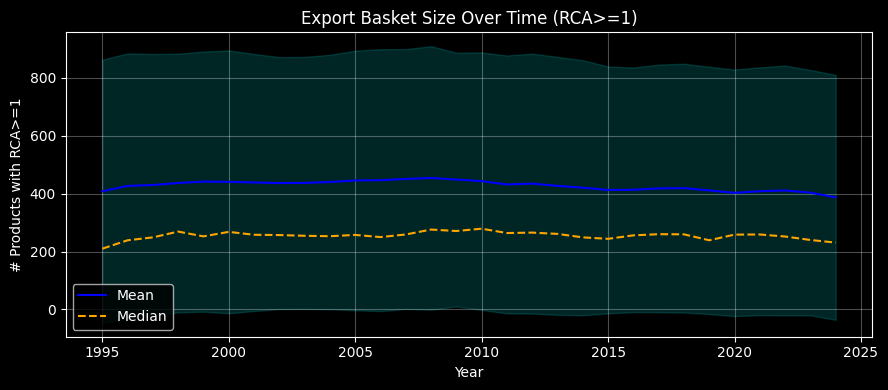

In [38]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(basket_agg["year"],
                basket_agg["mean"] - basket_agg["std"],
                basket_agg["mean"] + basket_agg["std"],
                alpha=0.15, color="cyan")
ax.plot(basket_agg["year"], basket_agg["mean"], color="blue", label="Mean")
ax.plot(basket_agg["year"], basket_agg["median"], color="orange", linestyle="--", label="Median")
ax.set_title("Export Basket Size Over Time (RCA>=1)")
ax.set_xlabel("Year")
ax.set_ylabel("# Products with RCA>=1")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "explore_basket_size.png"), dpi=150)
plt.show()

In [39]:
ubiquity = (panel[(panel["year"] == 2005) & (panel["rca_binary"] == 1)]
            .groupby("product")["country"].count())
ubiquity

product
010111    12
010119    28
010120     5
010210    31
010290    33
          ..
970200    16
970300    27
970400    45
970500    47
970600    34
Name: country, Length: 5008, dtype: int64

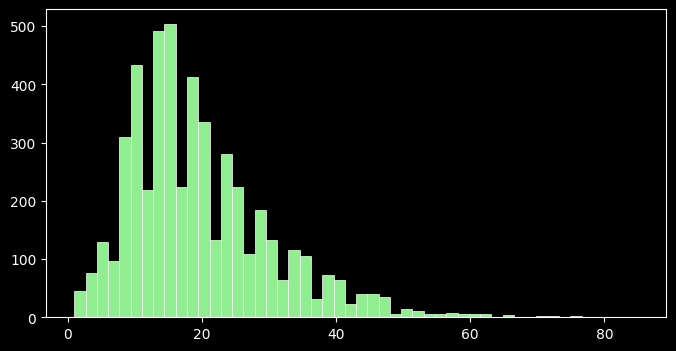

In [40]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ubiquity.values, bins=50, color="lightgreen", edgecolor="white", linewidth=0.5)
plt.show()

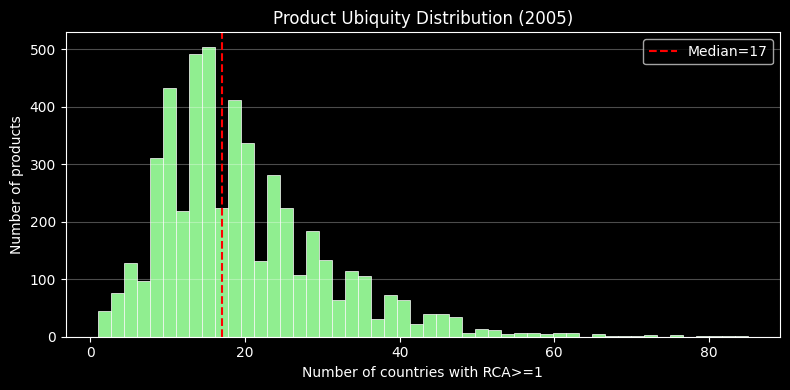

In [41]:
yr = 2005
ubiquity = (panel[(panel["year"] == yr) & (panel["rca_binary"] == 1)]
            .groupby("product")["country"].count())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ubiquity.values, bins=50, color="lightgreen", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Number of countries with RCA>=1")
ax.set_ylabel("Number of products")
ax.set_title(f"Product Ubiquity Distribution ({yr})")
ax.axvline(ubiquity.median(), color="red", linestyle="--", label=f"Median={ubiquity.median():.0f}")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "explore_ubiquity.png"), dpi=150)
plt.show()

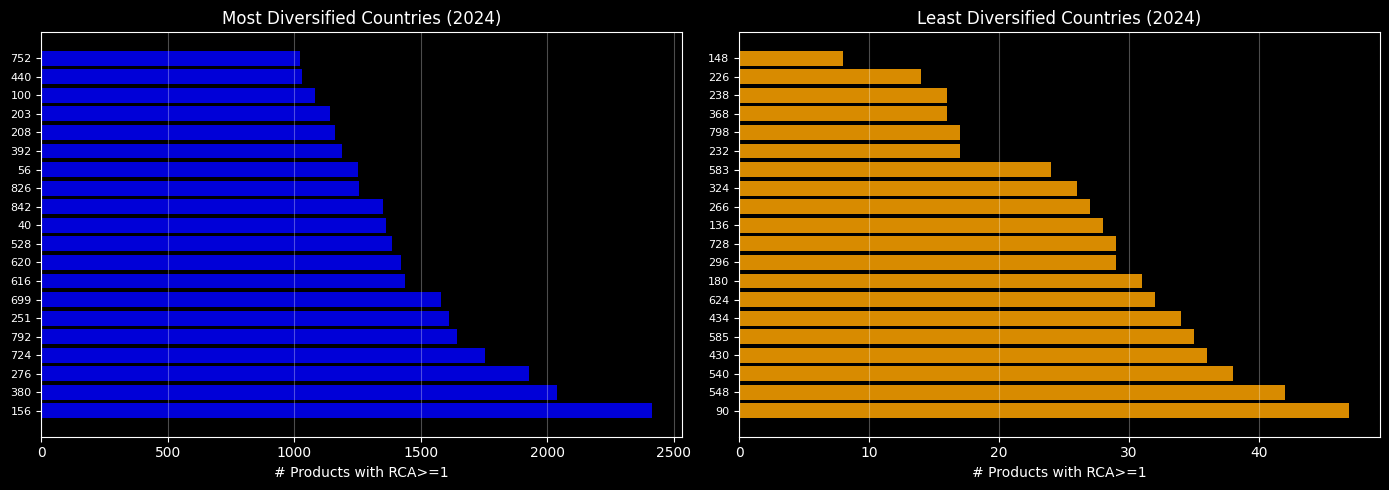

In [42]:
yr_latest = years[-1]
div = (panel[(panel["year"] == yr_latest) & (panel["rca_binary"] == 1)]
       .groupby("country")["product"].count().sort_values(ascending=False))

top20 = div.head(20)
bot20 = div.tail(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, title, color in zip(
        axes, [top20, bot20],
        [f"Most Diversified Countries ({yr_latest})",
         f"Least Diversified Countries ({yr_latest})"],
        ["blue", "orange"]):
    ax.barh(range(len(data)), data.values, color=color, alpha=0.85)
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data.index, fontsize=8)
    ax.set_xlabel("# Products with RCA>=1")
    ax.set_title(title)
    ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "explore_diversification.png"), dpi=150)
plt.show()

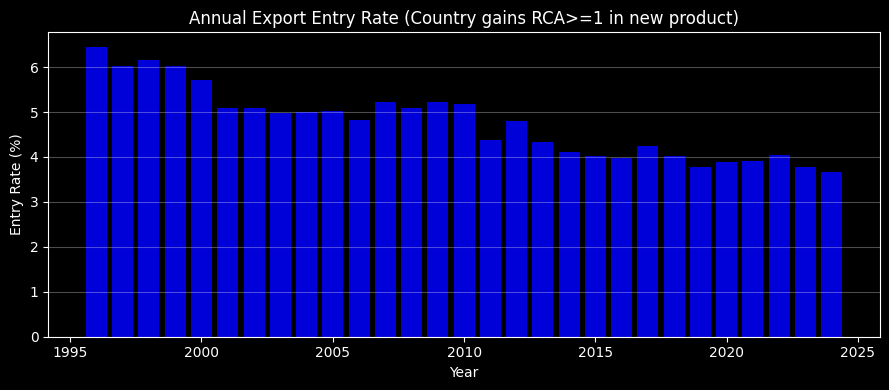

In [43]:
entry_rates = []
for i in range(len(years)-1):
    y0, y1 = years[i], years[i+1]
    sub0 = panel[panel["year"] == y0].set_index(["country","product"])["rca_binary"]
    sub1 = panel[panel["year"] == y1].set_index(["country","product"])["rca_binary"]
    common = sub0.index.intersection(sub1.index)
    no_rca = sub0[common] == 0
    gained = (sub0[common] == 0) & (sub1[common] == 1)
    if no_rca.sum() > 0:
        entry_rates.append({"year": y1, "entry_rate": gained.sum() / no_rca.sum()})

if entry_rates:
    er_df = pd.DataFrame(entry_rates)
    fig, ax = plt.subplots(figsize=(9,4))
    ax.bar(er_df["year"], er_df["entry_rate"]*100, color="blue", alpha=0.85)
    ax.set_xlabel("Year")
    ax.set_ylabel("Entry Rate (%)")
    ax.set_title("Annual Export Entry Rate (Country gains RCA>=1 in new product)")
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "explore_entry_rate.png"), dpi=150)
    plt.show()

In [44]:
print(f"Years available:     {years[0]}–{years[-1]}")
print(f"Countries:           {panel['country'].nunique()}")
print(f"Products:            {panel['product'].nunique()}")

yr_ref = 2005
basket_ref = basket[basket["year"] == yr_ref]["n_products"]
print(f"\nBasket size {yr_ref}:")
print(f"Mean:    {basket_ref.mean():.1f}")
print(f"Median:  {basket_ref.median():.1f}")
print(f"Std:     {basket_ref.std():.1f}")

print(f"\nProduct ubiquity ({yr_ref}):")
print(f"Mean:    {ubiquity.mean():.1f}")
print(f"Median:  {ubiquity.median():.1f}")

rca_density = panel[panel["year"]==yr_ref]["rca_binary"].mean()
print(f"RCA matrix density ({yr_ref}): {rca_density:.4f}")

Years available:     1995–2024
Countries:           233
Products:            5018

Basket size 2005:
Mean:    445.5
Median:  257.5
Std:     448.1

Product ubiquity (2005):
Mean:    19.7
Median:  17.0
RCA matrix density (2005): 0.1932
